# Convert our BiRefNet weights to onnx format.

> This colab file is modified from [Kazuhito00](https://github.com/Kazuhito00)'s nice work.

> Repo: https://github.com/Kazuhito00/BiRefNet-ONNX-Sample  
> Original Colab: https://colab.research.google.com/github/Kazuhito00/BiRefNet-ONNX-Sample/blob/main/Convert2ONNX.ipynb

+ Transforming a standard BiRefNet on GPU needs **19.7GB** GPU memory.
+ Currently, Colab with 12.7GB RAM / 15GB GPU Mem cannot hold the transformation of BiRefNet in default setting. So, I take BiRefNet with swin_v1_tiny backbone as an example on Colab.

### Online Colab version: https://colab.research.google.com/drive/1z6OruR52LOvDDpnp516F-N4EyPGrp5om

In [2]:
!pip install onnx onnxscript

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.4 MB 2.8 MB/s eta 0:00:06
   - -------------------------------------- 0.8/16.4 MB 2.2 MB/s eta 0:00:07
   ----- ---------------------------------- 2.1/16.4 MB 3.3 MB/s eta 0:00:05
   ------ --------------------------------- 2.6/16.4 MB 3.4 MB/s eta 0:00:05
   -------- ------------------------------- 3.4/16.4 MB 3.1 MB/s eta 0:00:05
   -------- ------------------------------- 3.7/16.4 MB 3.0 MB/s eta 0:00:05
   ---------- ----------------------------- 4.5/16.4 MB 2.9 MB/s eta 0:00:05
   ------------ --------------------------- 5.0/16.4 MB 2.9 MB/s eta 0:00:04
   ------------- -------------------------- 5.5/16.4 MB 2.8 MB/s eta 0:00:04
   -------------- ------

In [1]:
import torch


weights_file = 'BiRefNet_HR-matting-epoch_135.pth'  # https://github.com/ZhengPeng7/BiRefNet/releases/download/v1/BiRefNet_dynamic-general-epoch_174.pth
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
with open('config.py') as fp:
    file_lines = fp.read()
if 'swin_v1_tiny' in weights_file:
    print('Set `swin_v1_tiny` as the backbone.')
    file_lines = file_lines.replace(
        '''
            'pvt_v2_b2', 'pvt_v2_b5',               # 9-bs10, 10-bs5
        ][6]
        ''',
        '''
            'pvt_v2_b2', 'pvt_v2_b5',               # 9-bs10, 10-bs5
        ][3]
        ''',
    )
    with open('config.py', mode="w") as fp:
        fp.write(file_lines)
else:
    file_lines = file_lines.replace(
        '''
            'pvt_v2_b2', 'pvt_v2_b5',               # 9-bs10, 10-bs5
        ][3]
        ''',
        '''
            'pvt_v2_b2', 'pvt_v2_b5',               # 9-bs10, 10-bs5
        ][6]
        ''',
    )
    with open('config.py', mode="w") as fp:
        fp.write(file_lines)

In [3]:
from torch.onnx.symbolic_helper import parse_args
from torch.onnx import register_custom_op_symbolic


@parse_args(
    "v",  # arg0: input (tensor)
    "v",  # arg1: weight (tensor)
    "v",  # arg2: offset (tensor)
    "v",  # arg3: mask (tensor)
    "v",  # arg4: bias (tensor)
    "i",  # arg5: stride_h
    "i",  # arg6: stride_w
    "i",  # arg7: pad_h
    "i",  # arg8: pad_w
    "i",  # arg9: dilation_h
    "i",  # arg10: dilation_w
    "i",  # arg11: groups
    "i",  # arg12: deform_groups
    "b",  # arg13: some bool
)
def symbolic_deform_conv_19(
    g,
    input,
    weight,
    offset,
    mask,
    bias,
    stride_h,
    stride_w,
    pad_h,
    pad_w,
    dilation_h,
    dilation_w,
    groups,
    deform_groups,
    maybe_bool,
):
    strides = [stride_h, stride_w]
    pads = [pad_h, pad_w, pad_h, pad_w]
    dilations = [dilation_h, dilation_w]

    return g.op(
        "DeformConv",
        input,
        weight,
        offset,
        bias,
        mask,
        strides_i=strides,
        pads_i=pads,
        dilations_i=dilations,
        group_i=groups,
        offset_group_i=deform_groups,
        # You can ignore maybe_bool if you don't need it, or pass it as an attribute.
    )


register_custom_op_symbolic(
    "torchvision::deform_conv2d",  # PyTorch JIT/FX name
    symbolic_deform_conv_19,
    opset_version=19,
)

In [4]:
from utils import check_state_dict
from models.birefnet import BiRefNet


birefnet = BiRefNet(bb_pretrained=False)
state_dict = torch.load('./{}'.format(weights_file), map_location=device, weights_only=True)
state_dict = check_state_dict(state_dict)
birefnet.load_state_dict(state_dict)

torch.set_float32_matmul_precision(['highest'][0])

birefnet.to(device)
_ = birefnet.eval()

c:\Users\Anri\code\BiRefNet\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Process deform_conv2d in the conversion to ONNX

In [ ]:
def convert_to_onnx(net, file_name='output.onnx', input_shape=(2048, 2048), device=device):
    input = torch.randn(1, 3, input_shape[0], input_shape[1]).to(device)

    input_layer_names = ['input_image']
    output_layer_names = ['output_image']

    torch.onnx.export(
        net,
        input,
        file_name,
        verbose=False,
        dynamo=False,
        opset_version=19,
        input_names=input_layer_names,
        output_names=output_layer_names,
    )
convert_to_onnx(birefnet, weights_file.replace('.pth', '.onnx'), input_shape=(2048, 2048), device=device)

C:\Users\Anri\AppData\Local\Temp\ipykernel_28704\202448355.py:7: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


UnsupportedOperatorError: Exporting the operator 'torchvision::deform_conv2d' to ONNX opset version 18 is not supported. Support for this operator was added in version 19, try exporting with this version

# Load ONNX weights and do the inference.

In [2]:
from PIL import Image
from torchvision import transforms


transform_image = transforms.Compose([
    transforms.Resize((2048, 2048)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

imagepath = 'images_todo/0-onnx_test-2.jpg'
image = Image.open(imagepath)
image = image.convert("RGB") if image.mode != "RGB" else image
input_images = transform_image(image).unsqueeze(0).to('cpu')
input_images_numpy = input_images.cpu().numpy()

In [ ]:
import onnxruntime
import matplotlib.pyplot as plt

weights_file = 'BiRefNet_HR-matting-epoch_135.pth'


providers = ['CPUExecutionProvider']
onnx_session = onnxruntime.InferenceSession(
    weights_file.replace('.pth', '.onnx'),
    providers=providers
)
input_name = onnx_session.get_inputs()[0].name
print(onnxruntime.get_device(), onnx_session.get_providers())

CPU-DML ['CPUExecutionProvider']


29.84228253364563


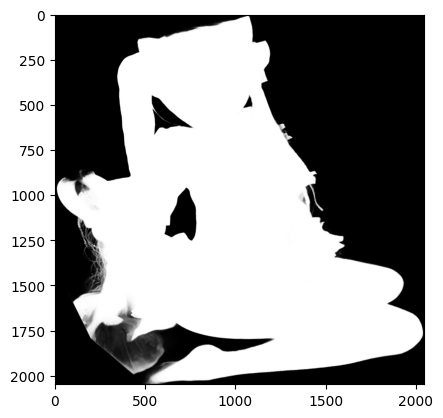

In [6]:
from time import time
import torch
import matplotlib.pyplot as plt

time_st = time()
pred_onnx = torch.tensor(
    onnx_session.run(None, {input_name: input_images_numpy})[-1]
).squeeze(0).sigmoid().cpu()
print(time() - time_st)

plt.imshow(pred_onnx.squeeze(), cmap='gray'); plt.show()

In [7]:
with torch.no_grad():
    preds = birefnet(input_images)[-1].sigmoid().to(torch.float32).cpu()
plt.imshow(preds.squeeze(), cmap='gray'); plt.show()

NameError: name 'birefnet' is not defined

In [ ]:
diff = abs(preds - pred_onnx)
print('sum(diff):', diff.sum())
plt.imshow((diff).squeeze(), cmap='gray'); plt.show()

# Efficiency Comparison between .pth and .onnx

In [ ]:
%%timeit
with torch.no_grad():
    preds = birefnet(input_images)[-1].sigmoid().to(torch.float32).cpu()

In [ ]:
%%timeit
pred_onnx = torch.tensor(
    onnx_session.run(None, {input_name: input_images_numpy})[-1]
).squeeze(0).sigmoid().cpu()